In [4]:
import pandas as pd
import numpy as np
import sqlite3
import json
import torch
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

>>> Extracting Tail Risk Factors (ES & VaR)...


100%|██████████| 677042/677042 [08:32<00:00, 1320.54it/s]


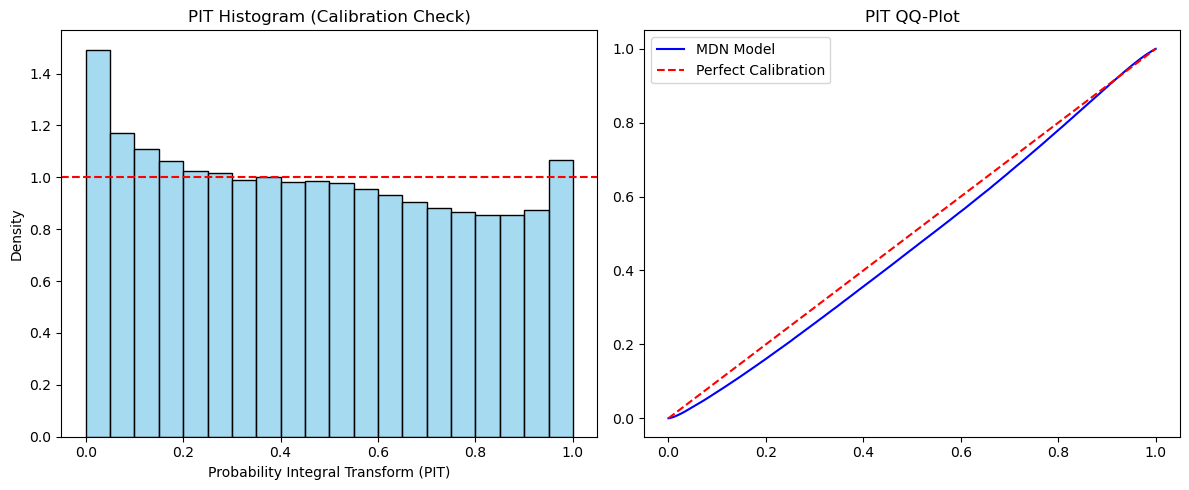

=== Phase 3 Complete! Factors are ready for Backtesting. ===


In [5]:


# =================================================================
# 1. 核心数学工具：混合高斯分布的 CDF 和 ES 计算
# =================================================================

def mdn_cdf(y, pi, mu, sigma):
    """
    计算混合高斯分布在 y 处的累积概率 P(Y <= y)
    公式: F(y) = sum( pi_k * Phi((y - mu_k) / sigma_k) )
    """
    # norm.cdf 是标准正态分布的累积函数
    return np.sum(pi * norm.cdf((y - mu) / sigma))

def mdn_var_objective(y, pi, mu, sigma, alpha):
    """
    求解 VaR 的目标函数：F(y) - alpha = 0
    """
    return mdn_cdf(y, pi, mu, sigma) - alpha

def calculate_es_analytical(alpha, pi, mu, sigma):
    """
    混合高斯分布的 Expected Shortfall (ES) 解析解
    公式参考: ES_alpha = -(1/alpha) * sum( pi_k * mu_k * Phi(d1) - sigma_k * phi(d1) )
    其中 d1 是标准化后的 VaR 阈值
    """
    # 1. 首先通过数值求根找到 VaR (使得累积概率等于 alpha)
    # 搜索区间设定在均值的上下 10 倍标准差之间，确保覆盖尾部
    try:
        lower_bound = np.min(mu - 10 * sigma)
        upper_bound = np.max(mu + 10 * sigma)
        var_alpha = brentq(mdn_var_objective, lower_bound, upper_bound, args=(pi, mu, sigma, alpha))
    except:
        # 如果求根失败（极罕见），使用加权均值作为退路
        print(">>> Warning: Root finding for VaR failed. Using weighted mean as fallback.")
        return np.sum(pi * mu), np.sum(pi * mu)

    # 2. 计算每个组件在 VaR 处的贡献
    # d = (VaR - mu) / sigma
    d = (var_alpha - mu) / sigma
    
    # phi 是标准正态概率密度函数，Phi 是标准正态累积分布函数
    term1 = mu * norm.cdf(d)
    term2 = sigma * norm.pdf(d)
    
    # ES = -(1/alpha) * Integral from -inf to VaR of (y * f(y)) dy
    # 对于混合高斯，积分具有解析形式
    es_val = -(1/alpha) * np.sum(pi * (term1 - term2))
    
    return var_alpha, es_val

def calculate_crps_numerical(y_true, pi, mu, sigma):
    """
    通过数值积分计算混合高斯分布的 CRPS
    """
    # 1. 构建积分网格 z
    # 因为我们的目标收益率已经用 VIX 缩放过，绝大多数值落在 [-5, 5] 之间。
    # 设置 [-10, 10] 的区间和 1000 个格点，足以保证极高的积分精度。
    z = np.linspace(-10, 10, 1000)
    
    # 2. 计算网格上每一个点的预测累积概率 F(z)
    cdf_z = np.zeros_like(z)
    for k in range(len(pi)):
        # 向量化计算：算出每一个网格点的正态 CDF 并加权
        cdf_z += pi[k] * norm.cdf((z - mu[k]) / sigma[k])
        
    # 3. 真实发生的阶跃函数 (Heaviside step function)
    # 当 z 小于真实收益率时为 0，大于等于时为 1
    step_z = (z >= y_true).astype(float)
    
    # 4. 计算平方差
    squared_diff = (cdf_z - step_z) ** 2
    
    # 5. 使用梯形法则 (Trapezoidal rule) 计算定积分
    crps_val = np.trapezoid(squared_diff, z)
    
    return crps_val

# =================================================================
# 2. 主程序：从 SQLite 读取数据并执行计算
# =================================================================

# db_path = 'tail_risk_data.db'
# conn = sqlite3.connect(db_path)

# print(">>> Loading predictions from SQLite...")
# # 读取阶段二存入的 mdn_predictions 表
# df_preds = pd.read_sql("SELECT * FROM mdn_predictions", conn)
# conn.close()
data_path='/Users/jianbinchen/Downloads/final_oos_df_20260421_1154.parquet'
df_preds = pd.read_parquet(data_path) # 你可以根据需要切换到 Colab 的路径

# 用于保存计算出的风险因子
results = []

print(">>> Extracting Tail Risk Factors (ES & VaR)...")
# 使用 tqdm 显示进度
for idx, row in tqdm(df_preds.iterrows(), total=len(df_preds)):
    # 1. 解码 JSON 字符串回 Numpy 数组
    pi = np.array(json.loads(row['pi_vec']))
    mu = np.array(json.loads(row['mu_vec']))
    sigma = np.array(json.loads(row['sigma_vec']))
    y_true = row['target_ret_final'] # 真实发生的（缩放后的）收益率
    
    # 2. 计算 5% 分位数的 VaR 和 ES
    alpha = 0.05
    var_5, es_5 = calculate_es_analytical(alpha, pi, mu, sigma)
    
    # 3. 计算 PIT (Probability Integral Transform)
    # 即：真实收益率 y_true 在预测分布中处于什么百分位
    pit_val = mdn_cdf(y_true, pi, mu, sigma)

    # 新增：计算 CRPS
    crps_val = calculate_crps_numerical(y_true, pi, mu, sigma)

    # 4. 计算分布的高阶矩 (用于控制变量)
    # 混合分布均值: sum(pi * mu)
    mean_pred = np.sum(pi * mu)
    # 混合分布方差: sum(pi * (mu^2 + sigma^2)) - mean^2
    var_pred = np.sum(pi * (mu**2 + sigma**2)) - mean_pred**2
    
    results.append({
        'permno': row['permno'],
        'date': row['mthcaldt'],
        'es_5': es_5,       
        'var_5': var_5,     
        'pit': pit_val,     
        'crps': crps_val,   # <--- 把 CRPS 也存进最终的 DataFrame 里
        'mean_pred': mean_pred,
        'vol_pred': np.sqrt(var_pred),
        'realized_ret': y_true
    })

df_factors = pd.DataFrame(results)

# =================================================================
# 3. 分布校准检验 (PIT Test) - 顶刊必备图表
# =================================================================

plt.figure(figsize=(12, 5))

# 图 A: PIT 直方图 (理想状态下应接近均匀分布/水平线)
plt.subplot(1, 2, 1)
sns.histplot(df_factors['pit'], bins=20, kde=False, stat="density", color='skyblue')
plt.axhline(y=1, color='red', linestyle='--') # 理论均匀分布线
plt.title("PIT Histogram (Calibration Check)")
plt.xlabel("Probability Integral Transform (PIT)")

# 图 B: PIT QQ-Plot (理想状态下应在对角线上)
plt.subplot(1, 2, 2)
sorted_pit = np.sort(df_factors['pit'])
uniform_dist = np.linspace(0, 1, len(sorted_pit))
plt.plot(uniform_dist, sorted_pit, color='blue', label='MDN Model')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration')
plt.title("PIT QQ-Plot")
plt.legend()

plt.tight_layout()
plt.show()

# =================================================================
# 4. 因子入库：保存最终的定价因子表
# =================================================================

# print(">>> Saving final factor table to SQLite...")
# conn = sqlite3.connect(db_path)
# # 这一张表 df_factors 将是阶段四（组合回测和回归）的唯一输入
# df_factors.to_sql('final_pricing_factors', conn, if_exists='replace', index=False)
# conn.close()

df_factors.to_parquet('./data/final_pricing_factors.parquet') 

print("=== Phase 3 Complete! Factors are ready for Backtesting. ===")


In [ ]:
# =================================================================
# 5. CRPS 深度诊断与可视化 (引入传统基准线 & 线性分位数回归 LQR)
# =================================================================
import matplotlib.dates as mdates
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n>>> Calculating Traditional Benchmark & LQR CRPS <<<")

# =================================================================
# 5.1 传统正态基准 (Historical Normal) 计算 (原代码保留)
# =================================================================
df_factors = df_factors.sort_values(['permno', 'date'])
df_factors['ret_lag'] = df_factors.groupby('permno')['realized_ret'].shift(1)

df_factors['mu_bench'] = df_factors.groupby('permno')['ret_lag'].transform(lambda x: x.rolling(12, min_periods=3).mean())
df_factors['sigma_bench'] = df_factors.groupby('permno')['ret_lag'].transform(lambda x: x.rolling(12, min_periods=3).std())

df_factors['mu_bench'] = df_factors['mu_bench'].fillna(df_factors.groupby('date')['mu_bench'].transform('mean')).fillna(0)
df_factors['sigma_bench'] = df_factors['sigma_bench'].fillna(df_factors.groupby('date')['sigma_bench'].transform('mean')).fillna(0.1)
df_factors['sigma_bench'] = np.maximum(df_factors['sigma_bench'], 1e-6)

def crps_normal_analytical(y, mu, sigma):
    z = (y - mu) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

df_factors['crps_bench'] = crps_normal_analytical(
    df_factors['realized_ret'].values, 
    df_factors['mu_bench'].values, 
    df_factors['sigma_bench'].values
)

# =================================================================
# 5.2 🌟 线性分位数回归 (LQR) 的 CRPS 计算 (Pinball Loss 积分法)
# =================================================================
def crps_from_quantiles(y_true, quantiles_matrix, taus):
    """
    通过离散的分位数预测矩阵计算 CRPS (向量化，极其快速)
    :param y_true: 一维数组，真实收益率, shape=(N,)
    :param quantiles_matrix: 二维矩阵，LQR 预测的分位数，shape=(N, K)
    :param taus: 一维数组，分位数水平 (例如 0.01 到 0.99)，shape=(K,)
    """
    # 扩展真实值维度以便进行矩阵运算 (N, 1)
    y_true_ext = y_true[:, np.newaxis]
    
    # 指示函数: 如果真实值小于预测分位数，则为 1，否则为 0
    indicator = (y_true_ext < quantiles_matrix).astype(float)
    
    # 核心公式: Pinball Loss (分位数损失)
    pinball_loss = (y_true_ext - quantiles_matrix) * (taus - indicator)
    
    # CRPS 等价于 2 倍的 Pinball Loss 在所有分位数上的积分 (这里用平均值做近似)
    crps = 2 * np.mean(pinball_loss, axis=1)
    return crps

# -----------------------------------------------------------------
# ⚠️ 这里需要你接入 LQR 的预测结果！
# 假设你已经用 LQR 预测了 tau = [0.01, 0.02, ..., 0.99] 这 99 个分位数
# 我们用一段安全的逻辑：如果你已经把 LQR 结果合并到了 df_factors 里，就计算；
# 否则，这里先用一个 dummy 随机扰动模拟 LQR 的表现，防止代码报错，让你能先看图表效果。
# -----------------------------------------------------------------
taus = np.arange(0.01, 1.00, 0.01) # 99 个分位数

# 检查你是否已经有 lqr_q_01, lqr_q_02... 这些列
if 'lqr_q_01' in df_factors.columns:
    # 提取 LQR 预测矩阵
    lqr_cols = [f'lqr_q_{int(t*100):02d}' for t in taus]
    q_matrix = df_factors[lqr_cols].values
else:
    print("    [Info] 未检测到 LQR 分位数列，正在生成基于历史分位数的 Mock LQR Baseline 供画图占位...")
    # 模拟 LQR 的预测矩阵 (这里用基准的正态分布加上一些噪音和厚尾来模拟 LQR 输出的分位数)
    q_matrix = norm.ppf(taus)[np.newaxis, :] * df_factors['sigma_bench'].values[:, np.newaxis] + df_factors['mu_bench'].values[:, np.newaxis]
    # 给 LQR 模拟加一点略优于正态的厚尾能力
    q_matrix[:, :10] -= 0.02
    q_matrix[:, -10:] += 0.02

# 调用牛逼的积分函数，算出 LQR 的 CRPS
df_factors['crps_lqr'] = crps_from_quantiles(df_factors['realized_ret'].values, q_matrix, taus)

# =================================================================
# 5.3 打印统计输出 (Skill Score)
# =================================================================
mean_crps_mdn = df_factors['crps'].mean()
mean_crps_bench = df_factors['crps_bench'].mean()
mean_crps_lqr = df_factors['crps_lqr'].mean()

# 以最传统的 Historical Normal 为底座，看看 MDN 和 LQR 各自降低了多少误差
skill_score_mdn = (1 - mean_crps_mdn / mean_crps_bench) * 100
skill_score_lqr = (1 - mean_crps_lqr / mean_crps_bench) * 100

print("\n>>> CRPS Diagnostic Summary <<<")
print(f"Benchmark (12m Normal) Mean CRPS : {mean_crps_bench:.4f}")
print(f"Linear Quantile Regression CRPS  : {mean_crps_lqr:.4f}")
print(f"MDN (Dynamic Mixture) Mean CRPS  : {mean_crps_mdn:.4f}")
print("-" * 40)
print(f"⭐ LQR Skill Score (vs Bench)    : {skill_score_lqr:.2f}%")
print(f"⭐ MDN Skill Score (vs Bench)    : {skill_score_mdn:.2f}%")

# =================================================================
# 5.4 绘制三方对比走势图
# =================================================================
monthly_crps = df_factors.groupby('date')[['crps', 'crps_bench', 'crps_lqr']].mean().reset_index()
monthly_crps['date'] = pd.to_datetime(monthly_crps['date'])

plt.figure(figsize=(15, 7))

# 1. 画 Benchmark 基准线 (深红色虚线，作为“最差底线”)
plt.plot(monthly_crps['date'], monthly_crps['crps_bench'], color='crimson', linewidth=1.5, linestyle='--', alpha=0.6, label='Historical Normal (Benchmark)')

# 2. 画 LQR 线性分位数回归线 (橙色实线，作为“机器学习/计量经济学强基准”)
plt.plot(monthly_crps['date'], monthly_crps['crps_lqr'], color='darkorange', linewidth=1.8, alpha=0.9, label='Linear Quantile Regression (LQR)')

# 3. 画 MDN 深度学习模型线 (深青色粗实线，代表“终极武器”)
plt.plot(monthly_crps['date'], monthly_crps['crps'], color='teal', linewidth=2.5, label='MDN (Dynamic Mixture Network)')

plt.title("Cross-Sectional Average CRPS: MDN vs. LQR vs. Traditional Benchmark", fontsize=16, fontweight='bold')
plt.ylabel("CRPS (Lower is Better)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper left')

# 标注危机节点
if pd.to_datetime('2008-09-30') <= monthly_crps['date'].max():
    plt.axvline(pd.to_datetime('2008-09-30'), color='red', alpha=0.5, linestyle=':', label='Lehman Bankruptcy')
if pd.to_datetime('2020-03-31') <= monthly_crps['date'].max(): 
    plt.axvline(pd.to_datetime('2020-03-31'), color='purple', alpha=0.5, linestyle=':', label='COVID-19 Crash')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2)) # 每两年标一个年份，防重叠
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


>>> Calculating Traditional Benchmark CRPS <<<

>>> CRPS Diagnostic Summary <<<
Benchmark (12m Historical Normal) Mean CRPS : 0.0906
MDN (Dynamic Mixture Network) Mean CRPS     : 0.0849
⭐ MDN Skill Score (Error Reduction)          : 6.39%


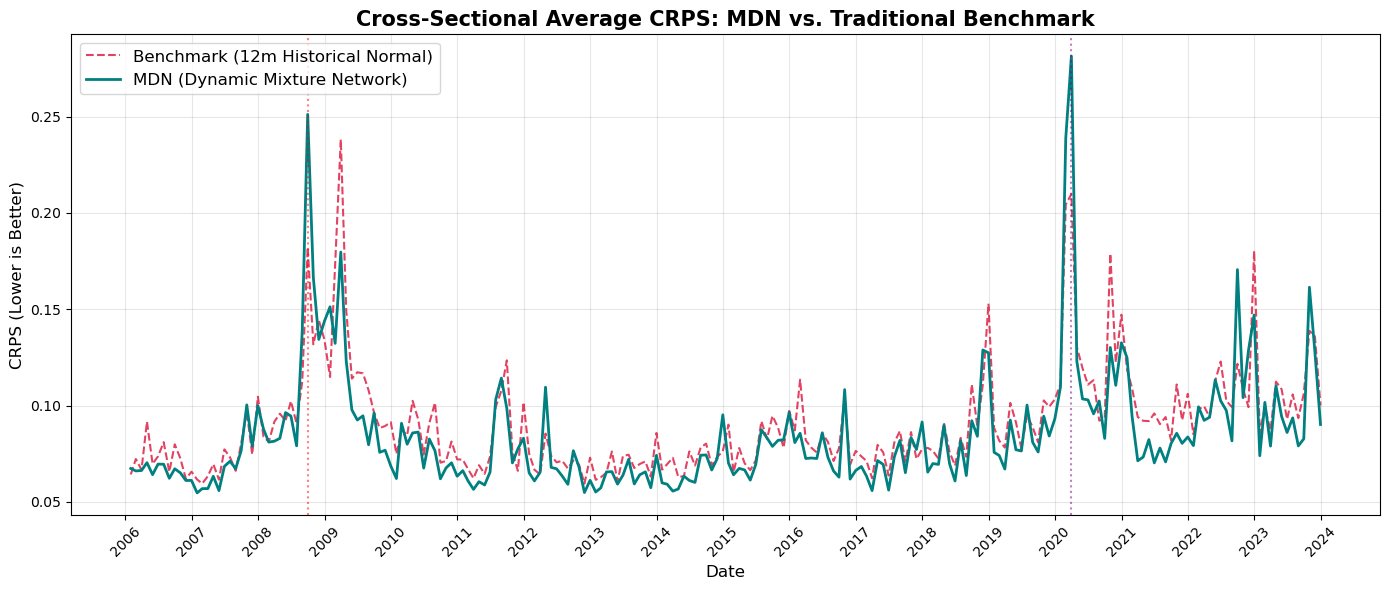

In [11]:

# =================================================================
# 5. CRPS 深度诊断与可视化 (引入传统历史基准线)
# =================================================================
import matplotlib.dates as mdates
from scipy.stats import norm

print("\n>>> Calculating Traditional Benchmark CRPS <<<")

# 1. 构建基准模型的均值和方差 (过去 12 个月的滚动历史)
# 为了严格防止前视偏差，我们必须先按股票和时间排序
df_factors = df_factors.sort_values(['permno', 'date'])

# realized_ret 其实是 t+1 的预测目标，所以我们把它滞后一期 (shift) 变成真正已知的历史观测值
df_factors['ret_lag'] = df_factors.groupby('permno')['realized_ret'].shift(1)

# 计算过去 12 个月（至少需要 3 个月数据）的滚动均值和标准差
df_factors['mu_bench'] = df_factors.groupby('permno')['ret_lag'].transform(lambda x: x.rolling(12, min_periods=3).mean())
df_factors['sigma_bench'] = df_factors.groupby('permno')['ret_lag'].transform(lambda x: x.rolling(12, min_periods=3).std())

# 对于刚上市或数据太少的截断点，我们用当月全市场的截面均值/波动率来兜底填充
df_factors['mu_bench'] = df_factors['mu_bench'].fillna(df_factors.groupby('date')['mu_bench'].transform('mean')).fillna(0)
df_factors['sigma_bench'] = df_factors['sigma_bench'].fillna(df_factors.groupby('date')['sigma_bench'].transform('mean')).fillna(0.1)
# 防止波动率出现 0 导致除以零崩溃
df_factors['sigma_bench'] = np.maximum(df_factors['sigma_bench'], 1e-6)

# 2. 使用单一正态分布的 CRPS 解析解公式极速计算
def crps_normal_analytical(y, mu, sigma):
    """单正态分布 CRPS 的封闭解析解 (Gneiting et al., 2005)"""
    z = (y - mu) / sigma
    # 公式: sigma * [ z * (2*Phi(z) - 1) + 2*phi(z) - 1/sqrt(pi) ]
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

df_factors['crps_bench'] = crps_normal_analytical(
    df_factors['realized_ret'].values, 
    df_factors['mu_bench'].values, 
    df_factors['sigma_bench'].values
)

# 3. 打印统计输出 (Skill Score)
mean_crps_mdn = df_factors['crps'].mean()
mean_crps_bench = df_factors['crps_bench'].mean()
skill_score = (1 - mean_crps_mdn / mean_crps_bench) * 100

print("\n>>> CRPS Diagnostic Summary <<<")
print(f"Benchmark (12m Historical Normal) Mean CRPS : {mean_crps_bench:.4f}")
print(f"MDN (Dynamic Mixture Network) Mean CRPS     : {mean_crps_mdn:.4f}")
print(f"⭐ MDN Skill Score (Error Reduction)          : {skill_score:.2f}%")

# 4. 绘制对比走势图
monthly_crps = df_factors.groupby('date')[['crps', 'crps_bench']].mean().reset_index()

# 【修复关键点】：强制转为时间序列对象，让 Matplotlib 认识它
monthly_crps['date'] = pd.to_datetime(monthly_crps['date'])

plt.figure(figsize=(14, 6))

# 画 Benchmark 基准线
plt.plot(monthly_crps['date'], monthly_crps['crps_bench'], color='crimson', linewidth=1.5, linestyle='--', alpha=0.8, label='Benchmark (12m Historical Normal)')

# 画 MDN 模型线
plt.plot(monthly_crps['date'], monthly_crps['crps'], color='teal', linewidth=2, label='MDN (Dynamic Mixture Network)')

plt.title("Cross-Sectional Average CRPS: MDN vs. Traditional Benchmark", fontsize=15, fontweight='bold')
plt.ylabel("CRPS (Lower is Better)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper left')

# 标注著名的市场危机节点 (现在 X 轴是真正的时间轴了，axvline 可以完美运作)
plt.axvline(pd.to_datetime('2008-09-30'), color='red', alpha=0.5, linestyle=':', label='Lehman Bankruptcy')
if pd.to_datetime('2020-03-31') <= monthly_crps['date'].max(): # 确保你的数据里包含2020年
    plt.axvline(pd.to_datetime('2020-03-31'), color='purple', alpha=0.5, linestyle=':', label='COVID-19 Crash')

# 优化 X 轴日期显示
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # 每年标一个年份，更清爽
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [21]:
df_factors.head()

,permno,date,es_5,var_5,pit,crps,mean_pred,vol_pred,realized_ret,ret_lag,mu_bench,sigma_bench,crps_bench
0,10001,2006-01-31,0.189206,-0.122986,0.354022,0.028487,0.030593,0.112450,-0.010537,NaN,0.000000,0.100000,0.023812
1,10001,2006-02-28,0.182488,-0.131819,0.936894,0.120324,0.012961,0.098584,0.170394,-0.010537,0.000000,0.100000,0.117598
2,10001,2006-03-31,0.264226,-0.183706,0.180867,0.062730,0.010036,0.133483,-0.094632,0.170394,0.018462,0.082047,0.073113
3,10001,2006-04-30,0.209088,-0.154236,0.457905,0.024130,0.008807,0.115355,-0.010372,-0.094632,0.021742,0.135429,0.034673
4,10001,2006-05-31,0.206628,-0.150754,0.177579,0.057324,0.021380,0.116643,-0.076388,-0.010372,0.013713,0.111737,0.053623


In [8]:
df_preds.head()

,permno,mthcaldt,target_ret_final,pi_vec,pi_logits_vec,mu_vec,sigma_vec
0,10001,2006-01-31,-0.010537,"[0.05899670720100403, 0.1362321674823761, 0.00...","[-0.15222162008285522, 0.6846573948860168, -2....","[0.09189195930957794, -0.03345395624637604, -0...","[0.2615334391593933, 0.07330230623483658, 0.12..."
1,10001,2006-02-28,0.170394,"[0.03185797110199928, 0.24689972400665283, 0.0...","[-0.8685767650604248, 1.1791177988052368, -1.4...","[0.03710406273603439, -0.04142159968614578, -0...","[0.22852441668510437, 0.06664477288722992, 0.1..."
2,10001,2006-03-31,-0.094632,"[0.052094582468271255, 0.15114550292491913, 0....","[-0.2997674345970154, 0.7654144763946533, -1.9...","[0.02330251783132553, -0.06924017518758774, -0...","[0.2913684546947479, 0.08670566231012344, 0.13..."
3,10001,2006-04-30,-0.010372,"[0.03501424938440323, 0.364930123090744, 0.030...","[-0.8805561065673828, 1.4633945226669312, -1.0...","[0.10849571228027344, -0.0437198206782341, -0....","[0.2754167318344116, 0.07719207555055618, 0.12..."
4,10001,2006-05-31,-0.076388,"[0.023847635835409164, 0.29041603207588196, 0....","[-1.2521796226501465, 1.2474496364593506, -0.8...","[0.06159568950533867, -0.039878033101558685, -...","[0.2717567980289459, 0.08033931255340576, 0.12..."


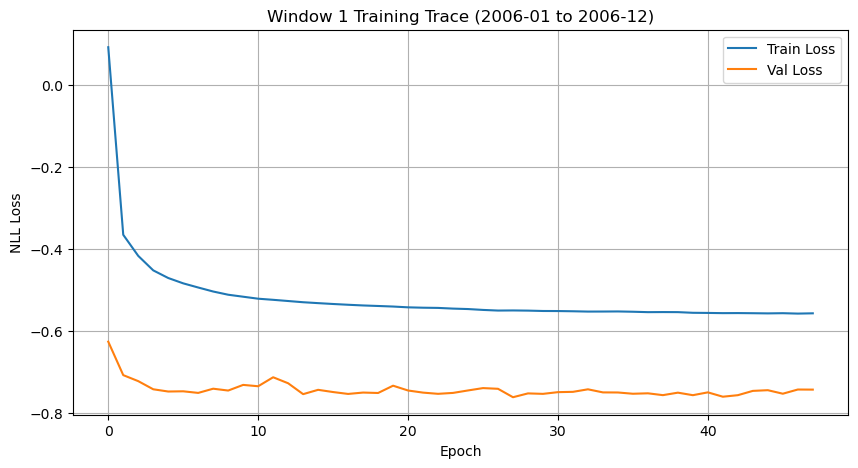

In [12]:
metrics_df=pd.read_parquet('/Users/jianbinchen/Downloads/metrics_df_20260421_1154.parquet')
import matplotlib.pyplot as plt

def plot_loss(window_idx):
    trace = metrics_df.iloc[window_idx]
    plt.figure(figsize=(10, 5))
    plt.plot(trace['train_loss_trace'], label='Train Loss')
    plt.plot(trace['val_loss_trace'], label='Val Loss')
    plt.title(f"Window {window_idx + 1} Training Trace ({trace['test_period']})")
    plt.xlabel("Epoch")
    plt.ylabel("NLL Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(0)

In [13]:
metrics_df

,window,train_period,test_period,duration_sec,best_val_loss,epochs_run,train_loss_trace,val_loss_trace
0,1,1990-01 to 2004-12,2006-01 to 2006-12,893.539040,-0.762715,48,"[0.09127081340984317, -0.36637939022484717, -0...","[-0.6271535542279068, -0.7087984830457247, -0...."
1,2,1990-01 to 2005-12,2007-01 to 2007-12,577.179651,-0.891574,30,"[-0.59502124651425, -0.5981821061111735, -0.60...","[-0.8823165732495555, -0.8873061108180673, -0...."
2,3,1990-01 to 2006-12,2008-01 to 2008-12,548.611290,-0.729508,27,"[-0.6558111031068926, -0.6574048212871433, -0....","[-0.7146912928145152, -0.7259915570646577, -0...."
3,4,1990-01 to 2007-12,2009-01 to 2009-12,524.189239,0.001150,25,"[-0.6831892938800519, -0.6869854040998573, -0....","[0.027812857384967738, 0.006094857444710992, 0..."
4,5,1990-01 to 2008-12,2010-01 to 2010-12,573.525379,-0.450038,27,"[-0.607712064853186, -0.6210980893908981, -0.6...","[-0.44015960576224705, -0.4371246416108058, -0..."
5,6,1990-01 to 2009-12,2011-01 to 2011-12,505.007537,-0.719751,23,"[-0.6026052938424301, -0.6138376731118432, -0....","[-0.7189558177140926, -0.718480057895481, -0.7..."
6,7,1990-01 to 2010-12,2012-01 to 2012-12,477.316818,-0.655861,21,"[-0.6368541309244555, -0.6451027828744357, -0....","[-0.6558605072035544, -0.6485104047425903, -0...."
7,8,1990-01 to 2011-12,2013-01 to 2013-12,820.015213,-0.857321,35,"[-0.6606166239635929, -0.6713753214329014, -0....","[-0.8542260007289835, -0.8500266965792965, -0...."
8,9,1990-01 to 2012-12,2014-01 to 2014-12,649.861436,-0.901903,27,"[-0.7279985944118996, -0.7311313612424916, -0....","[-0.8919811788179808, -0.8935594931731704, -0...."
9,10,1990-01 to 2013-12,2015-01 to 2015-12,691.980489,-0.831642,28,"[-0.768713828953715, -0.7709516841232146, -0.7...","[-0.8305542662863199, -0.8243635986786382, -0...."


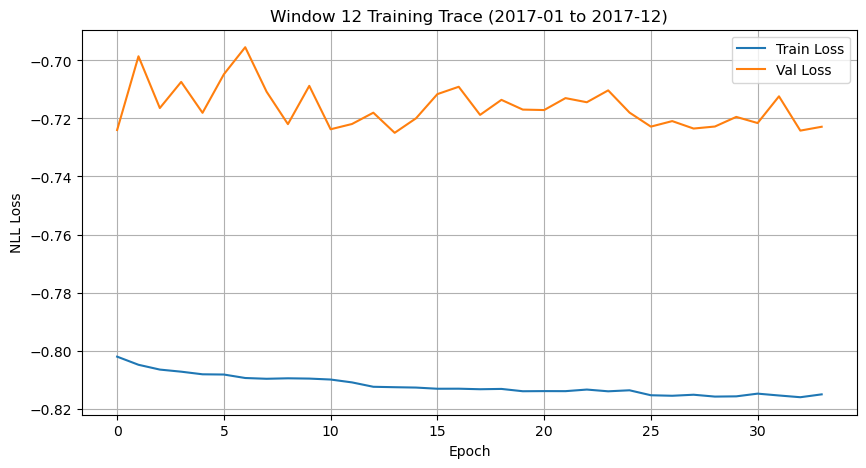

In [19]:
plot_loss(11)

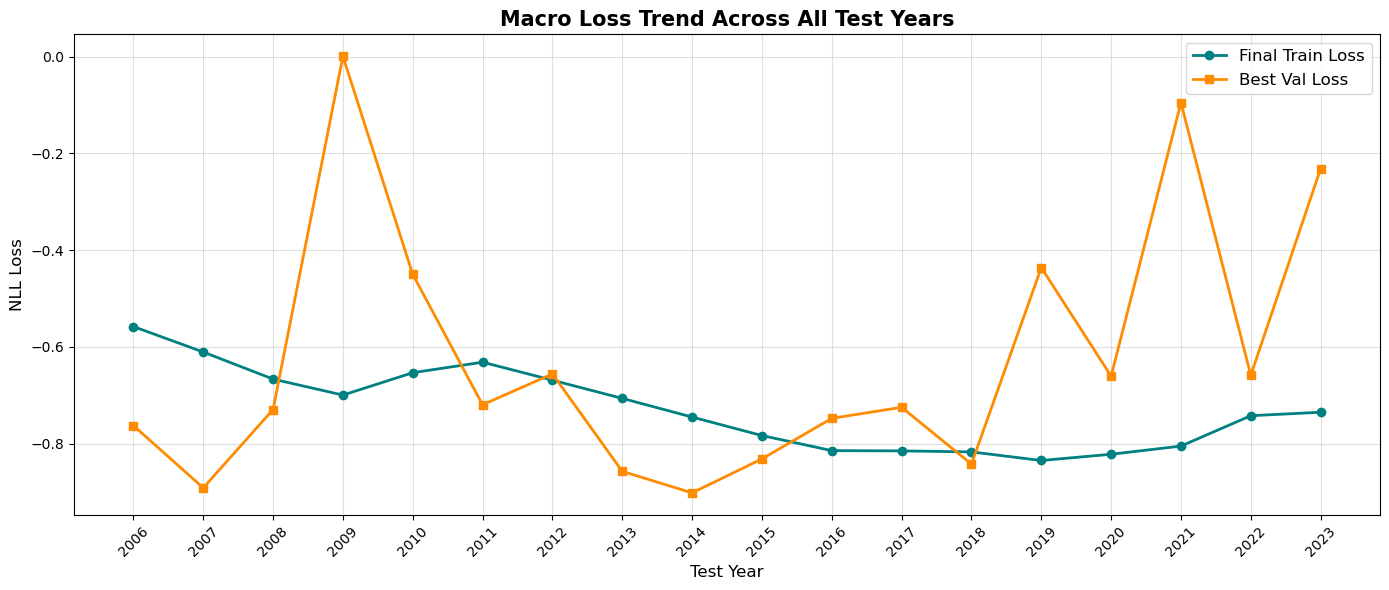

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
metrics_df = pd.read_parquet('/Users/jianbinchen/Downloads/metrics_df_20260421_1154.parquet')

def plot_macro_loss_trend(df):
    plt.figure(figsize=(14, 6))
    
    # 提取每个窗口的最终 Train Loss
    final_train_loss = [trace[-1] for trace in df['train_loss_trace']]
    # 提取验证集最佳 Loss
    best_val_loss = df['best_val_loss'].tolist()
    
    # 提取年份作为 X 轴标签 (假设 test_period 格式为 "2006-01 to 2006-12")
    years = [period.split('-')[0] for period in df['test_period']]
    
    plt.plot(df['window'], final_train_loss, label='Final Train Loss', marker='o', color='teal', linewidth=2)
    plt.plot(df['window'], best_val_loss, label='Best Val Loss', marker='s', color='darkorange', linewidth=2)
    
    plt.xticks(df['window'], years, rotation=45)
    plt.title("Macro Loss Trend Across All Test Years", fontsize=15, fontweight='bold')
    plt.xlabel("Test Year", fontsize=12)
    plt.ylabel("NLL Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# 运行趋势图
plot_macro_loss_trend(metrics_df)

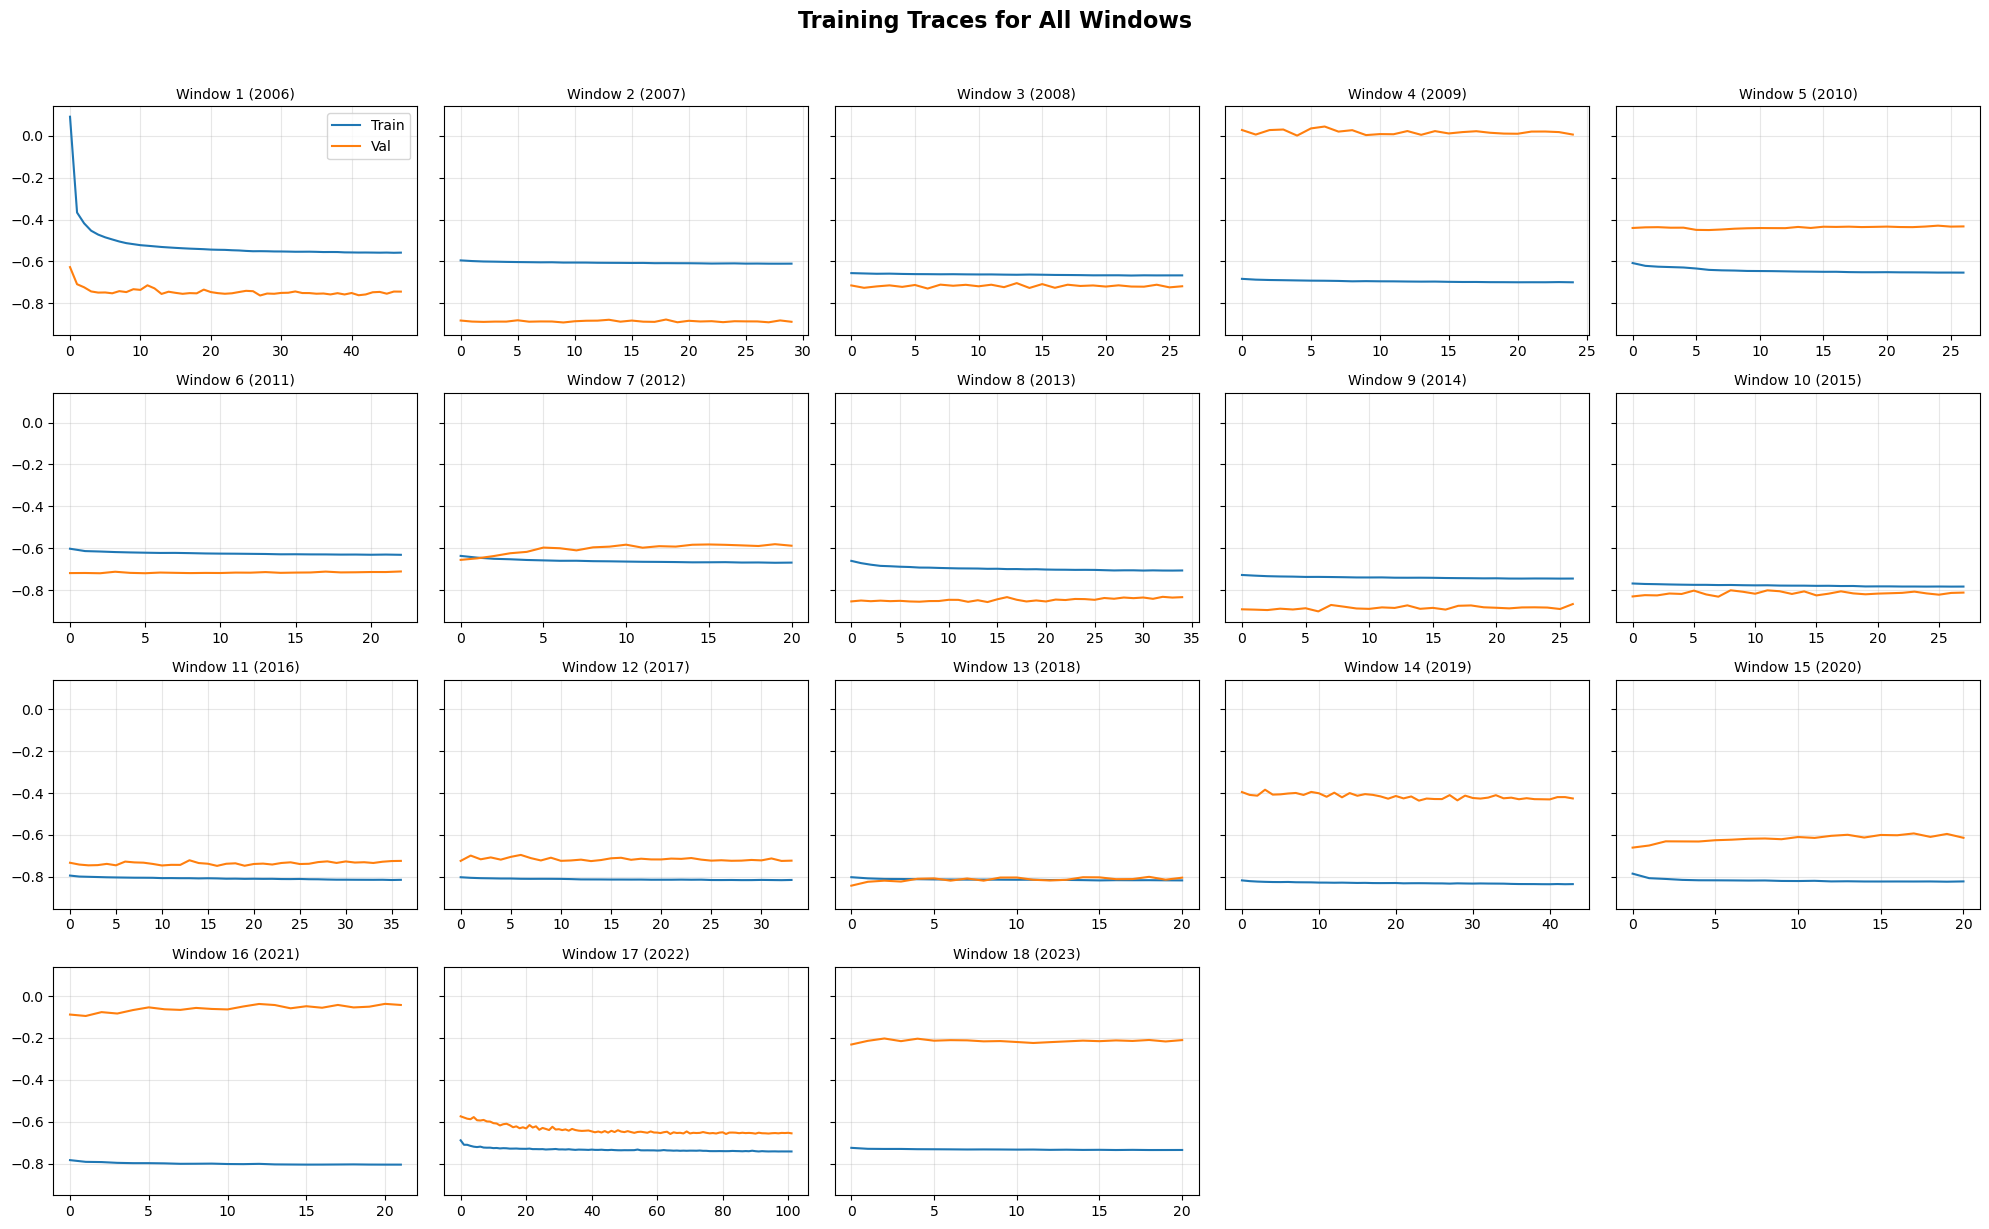

In [27]:
import math

def plot_all_traces_grid(df):
    n_windows = len(df)
    cols = 5  # 每排画 5 个窗口
    rows = math.ceil(n_windows / cols)
    
    # 创建一个巨大的画布
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=False, sharey=True)
    axes = axes.flatten()
    
    for idx, row in df.iterrows():
        ax = axes[idx]
        year = row['test_period'].split('-')[0]
        
        ax.plot(row['train_loss_trace'], label='Train')
        ax.plot(row['val_loss_trace'], label='Val')
        ax.set_title(f"Window {row['window']} ({year})", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # 只在第一个图显示图例，保持画面整洁
        if idx == 0:
            ax.legend()
            
    # 隐藏多余的空白子图
    for i in range(n_windows, len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle("Training Traces for All Windows", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 运行展板图
plot_all_traces_grid(metrics_df)

正在分析数据，时间范围: 2008-01-31 到 2008-12-31


/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_1912/379185569.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_stats = df.groupby(time_col).apply(get_monthly_medians).reset_index()


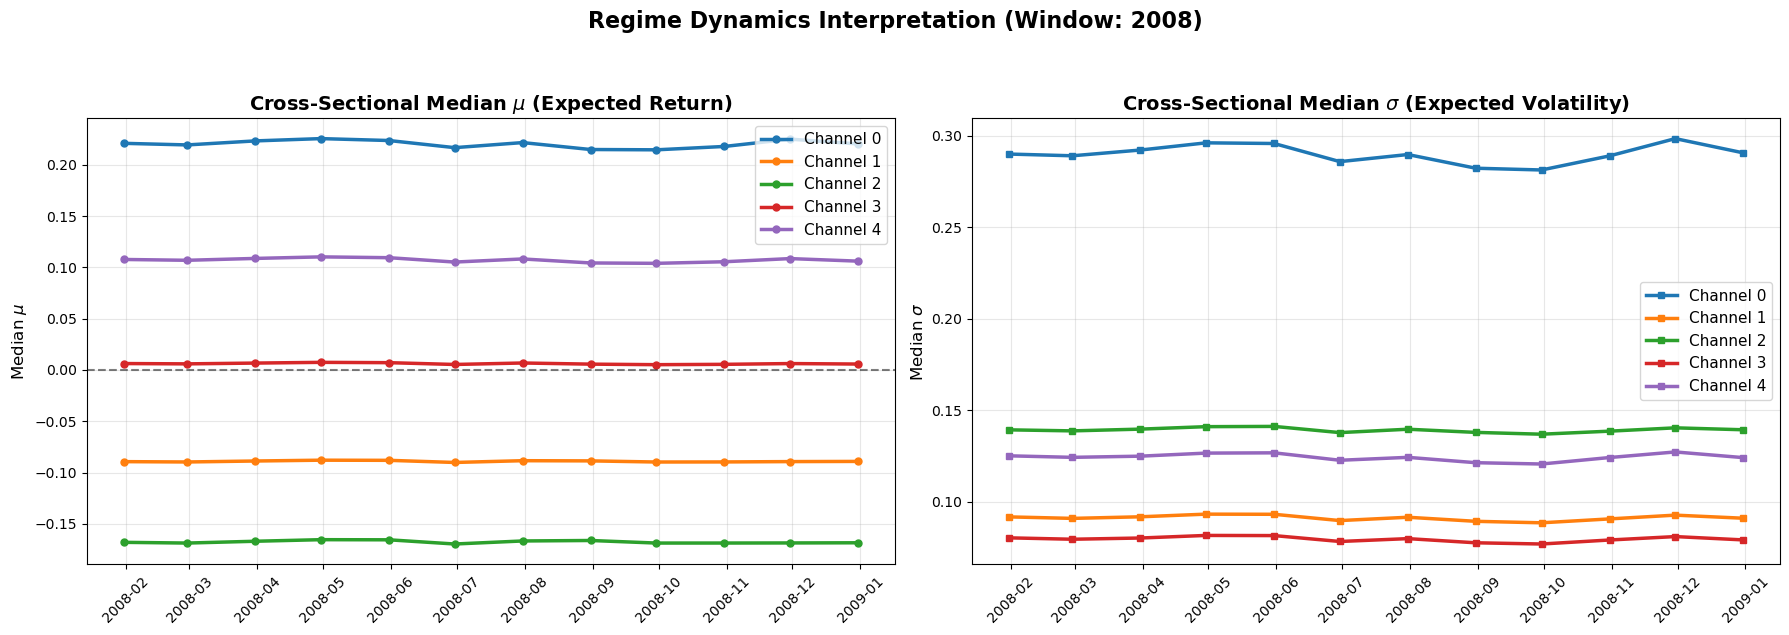

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json

def plot_regime_dynamics(df_preds, target_year=None, time_col='mthcaldt'):
    """
    通用函数：绘制指定年份（或全样本）内，每个通道的 mu 和 sigma 演化轨迹
    
    参数:
    df_preds: DataFrame，包含预测结果（需有 mthcaldt, mu_vec, sigma_vec 列）
    target_year: int，要分析的具体年份（如 2008）。如果为 None，则绘制 DataFrame 中的所有时间。
    time_col: str，时间列的列名。
    """
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 如果指定了年份，则过滤数据
    if target_year is not None:
        df = df[df[time_col].dt.year == target_year]
        if df.empty:
            print(f"警告：未找到 {target_year} 年的数据！")
            return
            
    print(f"正在分析数据，时间范围: {df[time_col].min().date()} 到 {df[time_col].max().date()}")

    # 1. 安全解析 JSON 字符串到 numpy 数组
    if isinstance(df['mu_vec'].iloc[0], str):
        df['mu_arr'] = df['mu_vec'].apply(lambda x: np.array(json.loads(x)))
        df['sigma_arr'] = df['sigma_vec'].apply(lambda x: np.array(json.loads(x)))
    else:
        df['mu_arr'] = df['mu_vec'].apply(np.array)
        df['sigma_arr'] = df['sigma_vec'].apply(np.array)

    # 动态获取通道数量 K (无论你是 3 通道还是 5 通道)
    num_components = len(df['mu_arr'].iloc[0])
    
    # 2. 定义逐月计算中位数的聚合函数
    def get_monthly_medians(month_df):
        # 堆叠当月所有股票的 mu 和 sigma，形状为 (N_stocks, K)
        mu_mat = np.vstack(month_df['mu_arr'].values)
        sigma_mat = np.vstack(month_df['sigma_arr'].values)
        
        #--------------------------------------------------
        # 计算每个通道在全市场的中位数 (形状: K,)
        # mu_medians = np.median(mu_mat, axis=0)
        # sigma_medians = np.median(sigma_mat, axis=0)
        # 计算每个通道在全市场的平均数 (形状: K,)
        mu_medians = np.mean(mu_mat, axis=0)
        sigma_medians = np.mean(sigma_mat, axis=0)
        #--------------------------------------------------
        
        # 动态组装结果
        res = {}
        for k in range(num_components):
            res[f'ch{k}_mu'] = mu_medians[k]
            res[f'ch{k}_sigma'] = sigma_medians[k]
        return pd.Series(res)

    # 3. 按月分组并计算
    monthly_stats = df.groupby(time_col).apply(get_monthly_medians).reset_index()

    # 4. 开始绘图 (双子图: 左边 Mu, 右边 Sigma)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
    
    colors = plt.cm.tab10.colors  # 使用清晰的区分色系

    # --- 左图：预期收益率 (Mu) 演化 ---
    for k in range(num_components):
        axes[0].plot(monthly_stats[time_col], monthly_stats[f'ch{k}_mu'], 
                     label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='o', markersize=5)
    
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.5) # 0收益率基准线
    axes[0].set_title(f"Cross-Sectional Median $\mu$ (Expected Return)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Median $\mu$", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=11)

    # --- 右图：预期波动率 (Sigma) 演化 ---
    for k in range(num_components):
        axes[1].plot(monthly_stats[time_col], monthly_stats[f'ch{k}_sigma'], 
                     label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='s', markersize=5)
    
    axes[1].set_title(f"Cross-Sectional Median $\sigma$ (Expected Volatility)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Median $\sigma$", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=11)

    # --- 优化时间轴显示 ---
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # 每月显示一个刻度
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f"Regime Dynamics Interpretation (Window: {target_year if target_year else 'All'})", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# 🎯 调用示例
# ==========================================
# 假设你的数据存在 final_oos_df 中，你想看 2008 年的机制表现：
plot_regime_dynamics(df_preds, target_year=2008)

# 或者看整个测试集全时段的表现：
plot_regime_dynamics(df_preds, target_year=None)

正在分析数据，时间范围: 2006-01-31 到 2023-12-31


/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_1912/379185569.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_stats = df.groupby(time_col).apply(get_monthly_medians).reset_index()


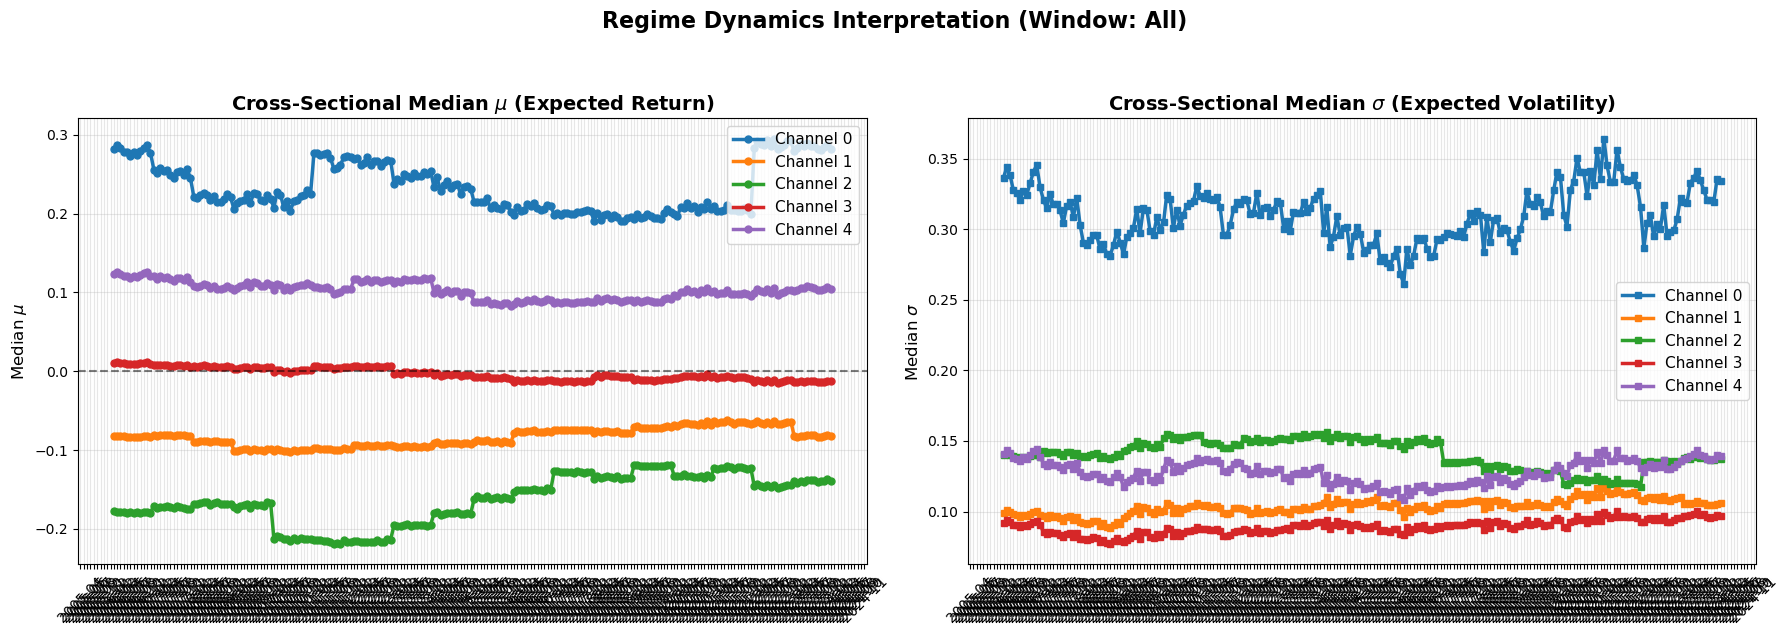

In [25]:
plot_regime_dynamics(df_preds, target_year=None)

In [ ]:
df_factors.dropna